In [2]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import sys
import os

# Add src directory to path for imports
sys.path.append('../src')

from anatomy import augment_image_with_random_scale_and_position, augment_bounding_box

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [3]:
# Load the NPZ file
npz_path = '../test_npz/train_1.npz'

if not os.path.exists(npz_path):
    print(f"❌ NPZ file not found at {npz_path}")
    print("Please run the NPZ extraction script first:")
    print("python scripts/extract_npz_files.py --single_case /tmp/chexsynth_test/projections/PA/train_1 --output_dir test_npz")
else:
    # Load the NPZ data
    data = np.load(npz_path, allow_pickle=True)
    image_array = data['img_array']
    metadata = data['metadata'].item()
    
    print(f"✅ Loaded NPZ file successfully")
    print(f"Case: {metadata['case']}")
    print(f"Orientation: {metadata['orientation']}")
    print(f"Image shape: {image_array.shape}")
    print(f"Number of structures: {metadata['num_structures']}")
    print(f"Available structures: {list(metadata['structure_info'].keys())[:10]}...")

✅ Loaded NPZ file successfully
Case: train_1
Orientation: PA
Image shape: (896, 896)
Number of structures: 79
Available structures: ['aorta', 'body', 'bones', 'brachiocephalic_vein_left', 'brachiocephalic_vein_right', 'bronchia', 'clavicula_left', 'clavicula_right', 'colon', 'costal_cartilages']...


In [4]:
# Select a structure for demonstration
# Let's use 'heart' as it's usually clearly visible
selected_structure = 'heart'

if selected_structure not in metadata['structure_info']:
    # If heart not available, pick the first available structure
    selected_structure = list(metadata['structure_info'].keys())[0]
    print(f"Heart not found, using '{selected_structure}' instead")

structure_info = metadata['structure_info'][selected_structure]
bbox_pixel = structure_info['bbox']  # Pixel coordinates
bbox_norm = structure_info['bbox_norm']  # Normalized coordinates

print(f"Selected structure: {selected_structure}")
print(f"Pixel bounding box: {bbox_pixel}")
print(f"Normalized bounding box: {bbox_norm}")

# Extract coordinates for visualization
y_min, x_min, y_max, x_max = bbox_pixel
bbox_width = x_max - x_min
bbox_height = y_max - y_min

Selected structure: heart
Pixel bounding box: (344, 309, 674, 690)
Normalized bounding box: (0.384, 0.345, 0.752, 0.77)


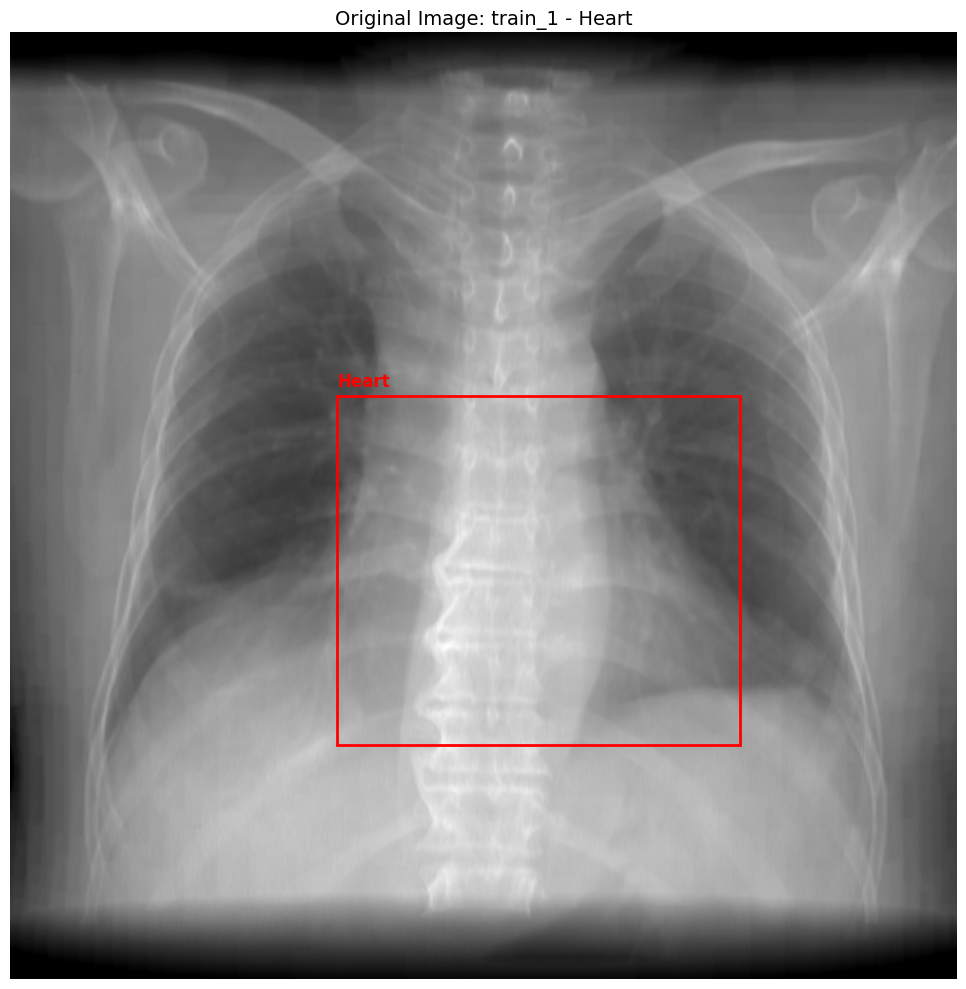

In [5]:
# Display original image with bounding box
plt.figure(figsize=(10, 10))
plt.imshow(image_array, cmap='gray')

# Add bounding box rectangle
rect = patches.Rectangle((x_min, y_min), bbox_width, bbox_height, 
                        linewidth=2, edgecolor='red', facecolor='none')
plt.gca().add_patch(rect)

# Add label
plt.text(x_min, y_min-10, f'{selected_structure.title()}', 
         color='red', fontsize=12, fontweight='bold')

plt.title(f'Original Image: {metadata["case"]} - {selected_structure.title()}', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

In [6]:
# Apply augmentation
print("Applying random scale and position augmentation...")

# Augment the image and get transformation parameters
augmented_image, transform_params = augment_image_with_random_scale_and_position(
    image_array, 
    scale_range=(0.7, 1.0),  # Random scale between 70%-100%
    background_value=0.0     # Black background
)

print(f"Transformation parameters:")
print(f"  Scale factor: {transform_params['scale_factor']:.3f}")
print(f"  X offset: {transform_params['x_offset']} pixels")
print(f"  Y offset: {transform_params['y_offset']} pixels")

Applying random scale and position augmentation...
Transformation parameters:
  Scale factor: 0.900
  X offset: 36 pixels
  Y offset: 53 pixels


In [7]:
# Transform the bounding box coordinates
augmented_bbox_pixel = augment_bounding_box(
    bbox_pixel, 
    transform_params, 
    image_array.shape
)

augmented_bbox_norm = augment_bounding_box(
    bbox_norm, 
    transform_params, 
    image_array.shape
)

print(f"Original pixel bbox: {bbox_pixel}")
print(f"Augmented pixel bbox: {augmented_bbox_pixel}")
print(f"")
print(f"Original normalized bbox: {bbox_norm}")
print(f"Augmented normalized bbox: {augmented_bbox_norm}")

# Extract augmented coordinates for visualization
aug_y_min, aug_x_min, aug_y_max, aug_x_max = augmented_bbox_pixel
aug_bbox_width = aug_x_max - aug_x_min
aug_bbox_height = aug_y_max - aug_y_min

Original pixel bbox: (344, 309, 674, 690)
Augmented pixel bbox: (362, 314, 659, 656)

Original normalized bbox: (0.384, 0.345, 0.752, 0.77)
Augmented normalized bbox: (0.40468163943798924, 0.3506155493834613, 0.7358144159232051, 0.7330379135307895)


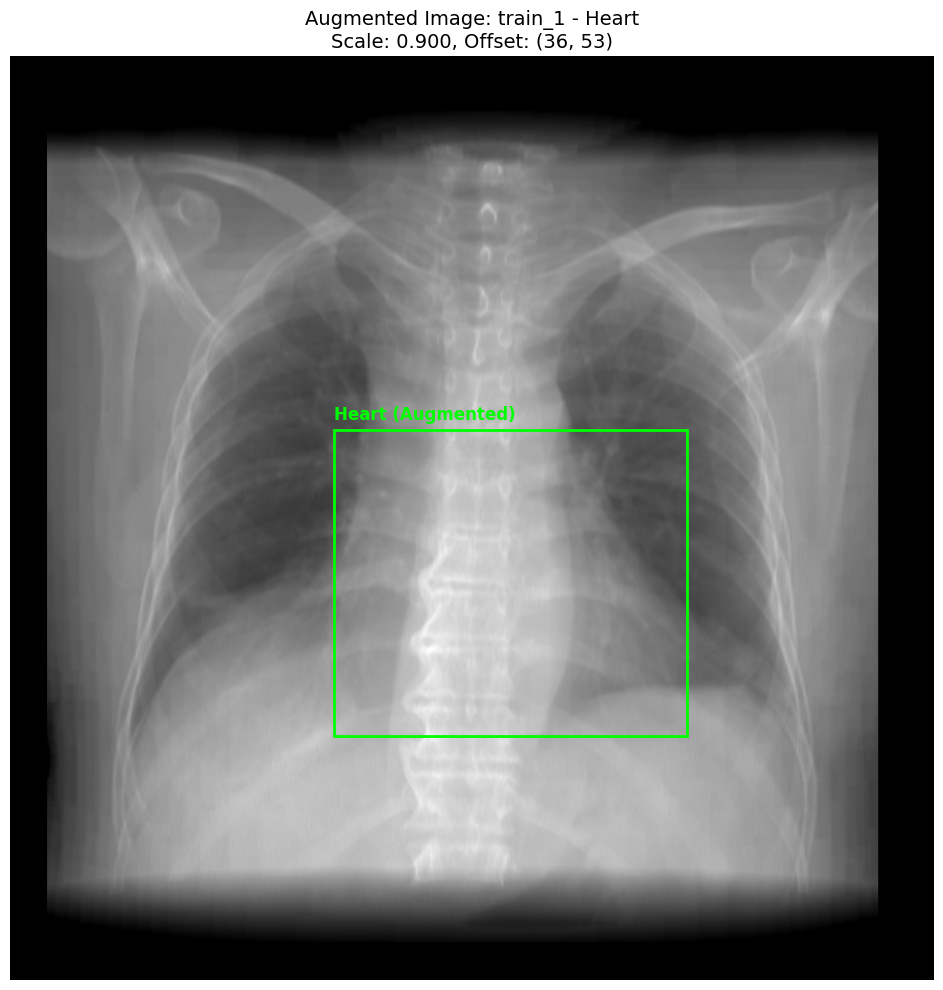

In [8]:
# Display augmented image with transformed bounding box
plt.figure(figsize=(10, 10))
plt.imshow(augmented_image, cmap='gray')

# Add transformed bounding box rectangle
rect_aug = patches.Rectangle((aug_x_min, aug_y_min), aug_bbox_width, aug_bbox_height,
                            linewidth=2, edgecolor='lime', facecolor='none')
plt.gca().add_patch(rect_aug)

# Add label
plt.text(aug_x_min, aug_y_min-10, f'{selected_structure.title()} (Augmented)', 
         color='lime', fontsize=12, fontweight='bold')

plt.title(f'Augmented Image: {metadata["case"]} - {selected_structure.title()}\n' + 
         f'Scale: {transform_params["scale_factor"]:.3f}, ' + 
         f'Offset: ({transform_params["x_offset"]}, {transform_params["y_offset"]})', 
         fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

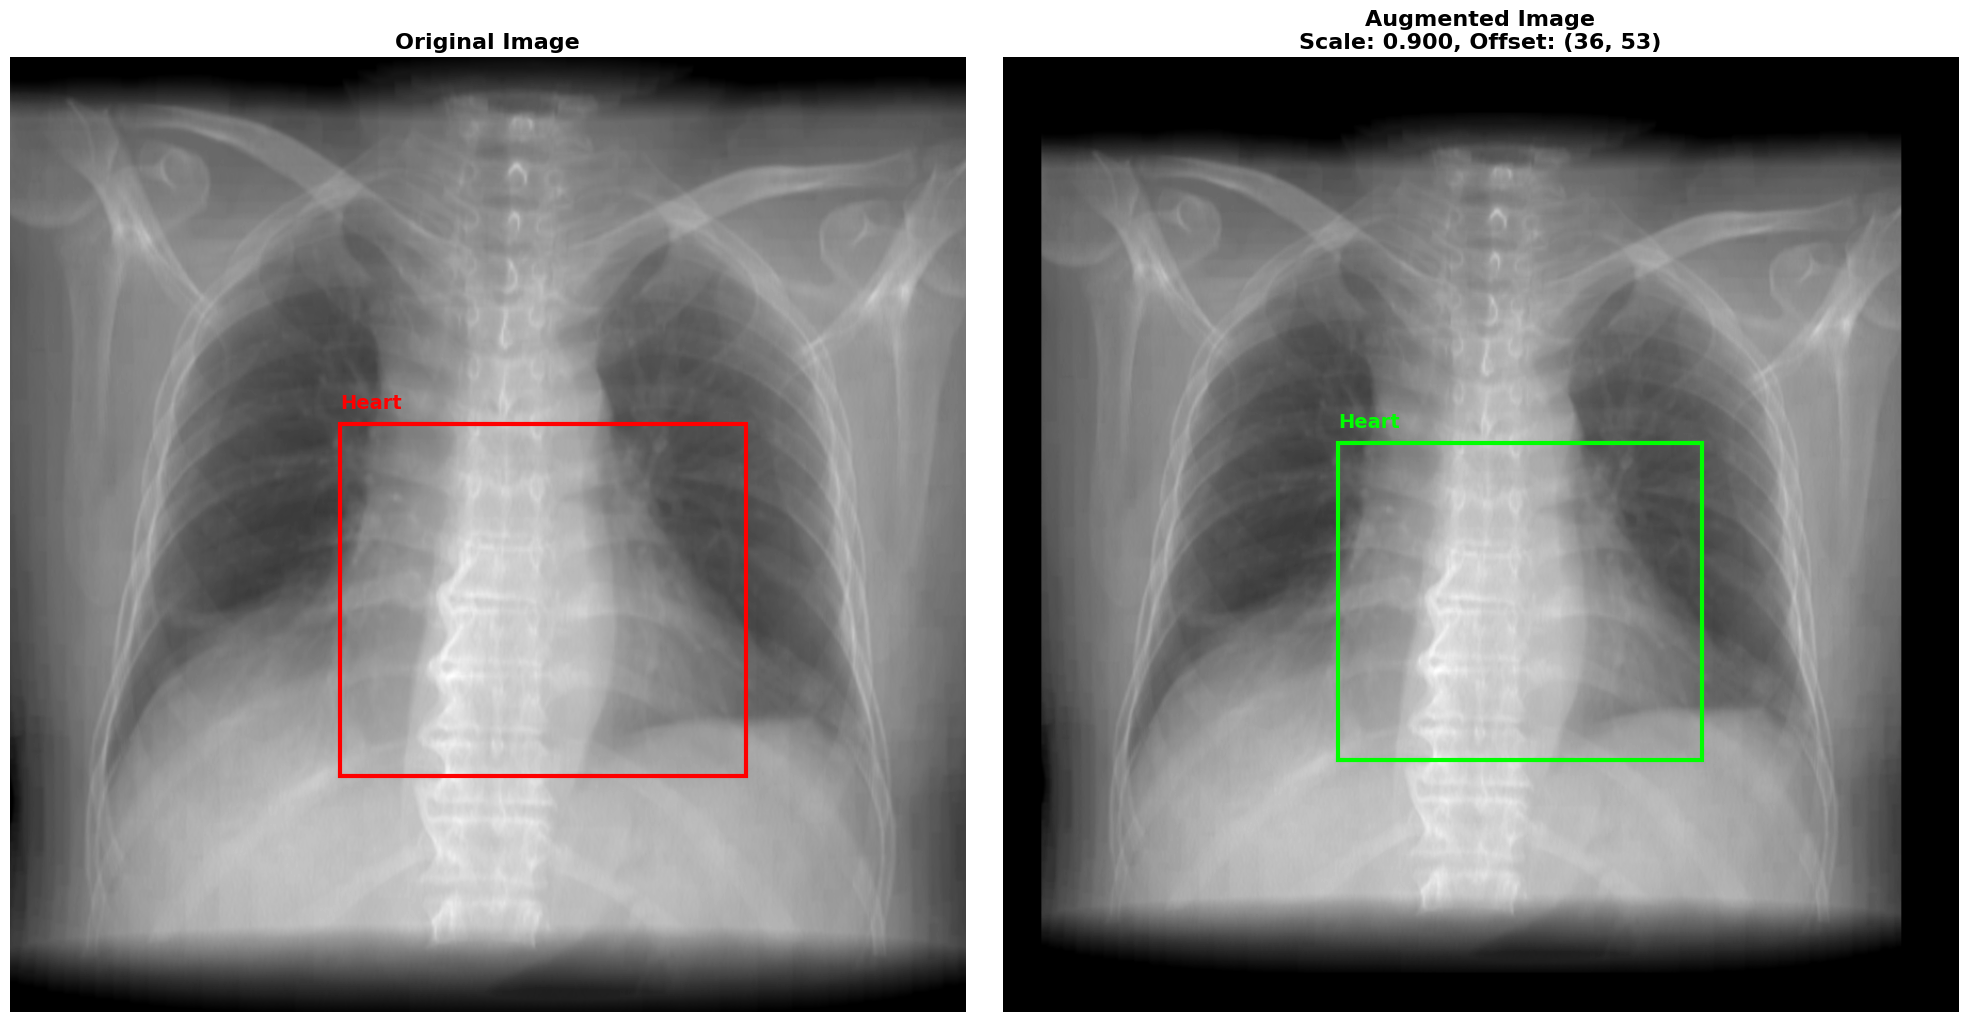

In [9]:
# Side-by-side comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Original image
ax1.imshow(image_array, cmap='gray')
rect1 = patches.Rectangle((x_min, y_min), bbox_width, bbox_height, 
                         linewidth=3, edgecolor='red', facecolor='none')
ax1.add_patch(rect1)
ax1.text(x_min, y_min-15, f'{selected_structure.title()}', 
         color='red', fontsize=14, fontweight='bold')
ax1.set_title('Original Image', fontsize=16, fontweight='bold')
ax1.axis('off')

# Augmented image
ax2.imshow(augmented_image, cmap='gray')
rect2 = patches.Rectangle((aug_x_min, aug_y_min), aug_bbox_width, aug_bbox_height,
                         linewidth=3, edgecolor='lime', facecolor='none')
ax2.add_patch(rect2)
ax2.text(aug_x_min, aug_y_min-15, f'{selected_structure.title()}', 
         color='lime', fontsize=14, fontweight='bold')
ax2.set_title(f'Augmented Image\nScale: {transform_params["scale_factor"]:.3f}, ' + 
             f'Offset: ({transform_params["x_offset"]}, {transform_params["y_offset"]})', 
             fontsize=16, fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.show()

In [10]:
# Summary of augmentation effects
print("=" * 60)
print("AUGMENTATION SUMMARY")
print("=" * 60)
print(f"Structure: {selected_structure.title()}")
print(f"")
print(f"Transformation Applied:")
print(f"  - Scale Factor: {transform_params['scale_factor']:.3f} ({transform_params['scale_factor']*100:.1f}% of original size)")
print(f"  - X Offset: {transform_params['x_offset']} pixels")
print(f"  - Y Offset: {transform_params['y_offset']} pixels")
print(f"")
print(f"Bounding Box Changes:")
print(f"  Original (pixels):  {bbox_pixel}")
print(f"  Augmented (pixels): {augmented_bbox_pixel}")
print(f"")
print(f"  Original (normalized):  {[f'{x:.3f}' for x in bbox_norm]}")
print(f"  Augmented (normalized): {[f'{x:.3f}' for x in augmented_bbox_norm]}")
print(f"")
print(f"✅ Image and bounding box augmentation completed successfully!")
print(f"The bounding box has been properly transformed to match the image augmentation.")

AUGMENTATION SUMMARY
Structure: Heart

Transformation Applied:
  - Scale Factor: 0.900 (90.0% of original size)
  - X Offset: 36 pixels
  - Y Offset: 53 pixels

Bounding Box Changes:
  Original (pixels):  (344, 309, 674, 690)
  Augmented (pixels): (362, 314, 659, 656)

  Original (normalized):  ['0.384', '0.345', '0.752', '0.770']
  Augmented (normalized): ['0.405', '0.351', '0.736', '0.733']

✅ Image and bounding box augmentation completed successfully!
The bounding box has been properly transformed to match the image augmentation.


# Segmentation Mask Augmentation

Now let's demonstrate how to augment segmentation masks along with the images. We'll:
1. Get the original segmentation token
2. Update it with the new bounding box coordinates 
3. Decode the segmentation mask from the updated tokens
4. Visualize the original and augmented segmentation masks

In [11]:
# Import additional functions for token updates and segmentation decoding
# First check if functions are available, then import
import importlib
import anatomy

# Reload anatomy module to get latest functions
importlib.reload(anatomy)

# Import the functions
from anatomy import update_bounding_box_token, update_segmentation_token

print("✅ Successfully imported token update functions")

# Check if the selected structure has segmentation tokens
original_seg_token = structure_info.get('segmentation_token')
original_bbox_token = structure_info.get('bbox_token')

if original_seg_token and original_bbox_token:
    print(f"✅ Found segmentation and bbox tokens for '{selected_structure}'")
    print(f"Original bbox token: {original_bbox_token[:40]}...")
    print(f"Original seg token length: {len(original_seg_token)} characters")
    print(f"Original seg token preview: {original_seg_token[:60]}...")
else:
    print(f"❌ No segmentation tokens found for '{selected_structure}'")
    print("Available structures with segmentation tokens:")
    for name, info in metadata['structure_info'].items():
        if info.get('segmentation_token'):
            print(f"  - {name}")
            # Switch to first available structure with segmentation tokens
            if selected_structure == structure_info['label'] and not original_seg_token:
                selected_structure = name
                structure_info = info
                original_seg_token = info['segmentation_token']
                original_bbox_token = info['bbox_token']
                bbox_pixel = info['bbox']
                bbox_norm = info['bbox_norm']
                print(f"\nSwitched to '{selected_structure}' for segmentation demo")
                break

✅ Successfully imported token update functions
✅ Found segmentation and bbox tokens for 'heart'
Original bbox token: <loc0393><loc0353><loc0769><loc0788>...
Original seg token length: 164 characters
Original seg token preview: <loc0393><loc0353><loc0769><loc0788><seg103><seg121><seg008>...


In [12]:
# Update the tokens with the augmented bounding box coordinates
if original_seg_token and original_bbox_token:
    # Update the bounding box token with augmented coordinates
    new_bbox_token = update_bounding_box_token(augmented_bbox_pixel, image_array.shape)
    
    # Update the segmentation token (replace bbox tokens, keep seg tokens)
    new_seg_token = update_segmentation_token(original_seg_token, new_bbox_token)
    
    print("Token Updates:")
    print(f"Original bbox token: {original_bbox_token}")
    print(f"Updated bbox token:  {new_bbox_token}")
    print(f"")
    print(f"Original seg token:  {original_seg_token[:60]}...")
    print(f"Updated seg token:   {new_seg_token[:60]}...")
    print(f"")
    print(f"Seg tokens preserved: {original_seg_token[36:] == new_seg_token[36:]}")  # After 4 bbox tokens

Token Updates:
Original bbox token: <loc0393><loc0353><loc0769><loc0788>
Updated bbox token:  <loc0413><loc0359><loc0752><loc0749>

Original seg token:  <loc0393><loc0353><loc0769><loc0788><seg103><seg121><seg008>...
Updated seg token:   <loc0413><loc0359><loc0752><loc0749><seg103><seg121><seg008>...

Seg tokens preserved: True


In [13]:
# Import segmentation decoding from the main decoder module
import sys
sys.path.insert(0, '../src')
import importlib

# Import the decoder module and reload it
import decoder
importlib.reload(decoder)

# Import the extract_objs function
from decoder import extract_objs

# Get image dimensions
height, width = image_array.shape[:2]
print(f"Image dimensions: {width}x{height}")

# Use the tokens we created earlier
print(f"Original segmentation token: {original_seg_token[:100]}...")
print(f"New segmentation token: {new_seg_token[:100]}...")

# Extract segmentation object from original data
segmentation_object = extract_objs(original_seg_token, width, height)
print(f"Found {len(segmentation_object)} objects in original image")

# Extract segmentation object from augmented data  
augmented_segmentation_object = extract_objs(new_seg_token, width, height)
print(f"Found {len(augmented_segmentation_object)} objects in augmented image")

# Extract the masks
original_mask = None
augmented_mask = None

for obj in segmentation_object:
    if 'mask' in obj and obj['mask'] is not None:
        original_mask = obj['mask']
        break

for obj in augmented_segmentation_object:
    if 'mask' in obj and obj['mask'] is not None:
        augmented_mask = obj['mask']
        break

print(f"Original mask extracted: {original_mask is not None}")
print(f"Augmented mask extracted: {augmented_mask is not None}")

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Image dimensions: 896x896
Original segmentation token: <loc0393><loc0353><loc0769><loc0788><seg103><seg121><seg008><seg111><seg073><seg122><seg108><seg068>...
New segmentation token: <loc0413><loc0359><loc0752><loc0749><seg103><seg121><seg008><seg111><seg073><seg122><seg108><seg068>...
Found 1 objects in original image
Found 1 objects in augmented image
Original mask extracted: True
Augmented mask extracted: True


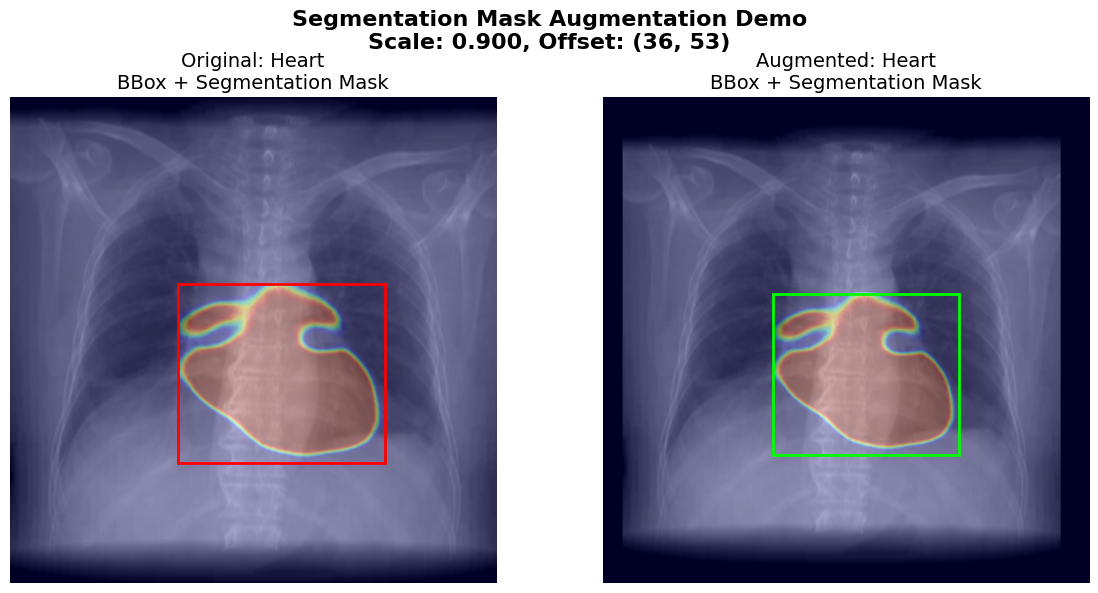

In [14]:
# Display original image with segmentation mask overlay
if original_mask is not None:
    plt.figure(figsize=(12, 6))
    
    # Original image with segmentation overlay
    plt.subplot(1, 2, 1)
    plt.imshow(image_array, cmap='gray')
    plt.imshow(original_mask, cmap='jet', alpha=0.3)
    
    # Add bounding box
    rect_orig = patches.Rectangle((x_min, y_min), bbox_width, bbox_height, 
                                 linewidth=2, edgecolor='red', facecolor='none')
    plt.gca().add_patch(rect_orig)
    
    plt.title(f'Original: {selected_structure.title()}\nBBox + Segmentation Mask', fontsize=14)
    plt.axis('off')
    
    # Augmented image with segmentation overlay
    plt.subplot(1, 2, 2)
    plt.imshow(augmented_image, cmap='gray')
    plt.imshow(augmented_mask, cmap='jet', alpha=0.3)
    
    # Add augmented bounding box
    rect_aug = patches.Rectangle((aug_x_min, aug_y_min), aug_bbox_width, aug_bbox_height,
                                linewidth=2, edgecolor='lime', facecolor='none')
    plt.gca().add_patch(rect_aug)
    
    plt.title(f'Augmented: {selected_structure.title()}\nBBox + Segmentation Mask', fontsize=14)
    plt.axis('off')
    
    plt.suptitle(f'Segmentation Mask Augmentation Demo\nScale: {transform_params["scale_factor"]:.3f}, ' + 
                 f'Offset: ({transform_params["x_offset"]}, {transform_params["y_offset"]})', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("❌ Cannot display segmentation masks - decoding failed")

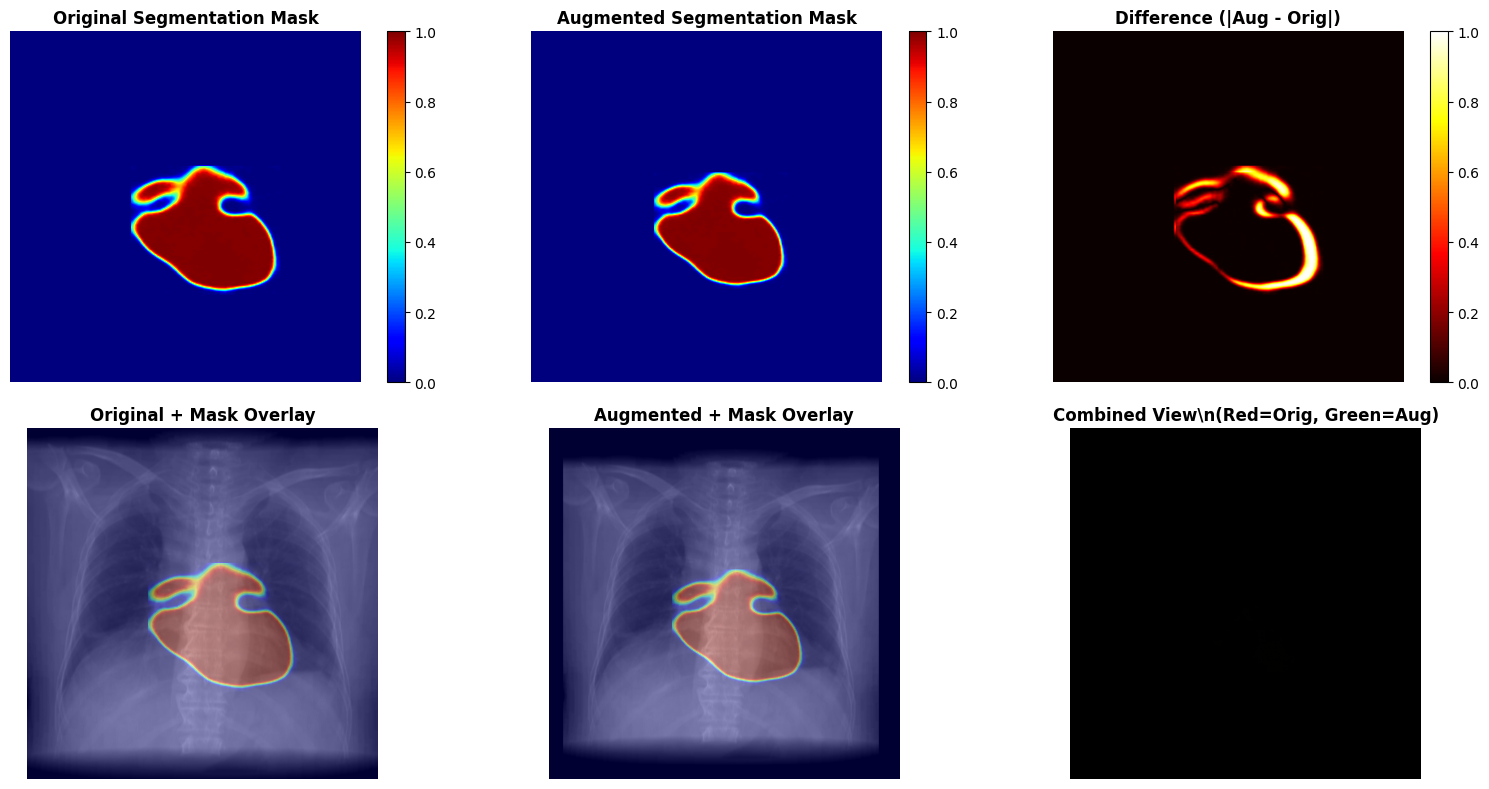

In [15]:
# Show detailed comparison of segmentation masks
if original_mask is not None and augmented_mask is not None:
    plt.figure(figsize=(16, 8))
    
    # Original segmentation mask only
    plt.subplot(2, 3, 1)
    plt.imshow(original_mask, cmap='jet')
    plt.title('Original Segmentation Mask', fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.colorbar()
    
    # Augmented segmentation mask only
    plt.subplot(2, 3, 2)
    plt.imshow(augmented_mask, cmap='jet')
    plt.title('Augmented Segmentation Mask', fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.colorbar()
    
    # Difference mask
    plt.subplot(2, 3, 3)
    diff_mask = np.abs(augmented_mask.astype(float) - original_mask.astype(float))
    plt.imshow(diff_mask, cmap='hot')
    plt.title('Difference (|Aug - Orig|)', fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.colorbar()
    
    # Original image with mask overlay
    plt.subplot(2, 3, 4)
    plt.imshow(image_array, cmap='gray')
    plt.imshow(original_mask, cmap='jet', alpha=0.4)
    plt.title('Original + Mask Overlay', fontsize=12, fontweight='bold')
    plt.axis('off')
    
    # Augmented image with mask overlay
    plt.subplot(2, 3, 5)
    plt.imshow(augmented_image, cmap='gray')
    plt.imshow(augmented_mask, cmap='jet', alpha=0.4)
    plt.title('Augmented + Mask Overlay', fontsize=12, fontweight='bold')
    plt.axis('off')
    
    # Side-by-side mask comparison
    plt.subplot(2, 3, 6)
    combined_mask = np.zeros((*original_mask.shape, 3))
    combined_mask[:, :, 0] = original_mask / 255.0      # Red channel for original
    combined_mask[:, :, 1] = augmented_mask / 255.0     # Green channel for augmented
    plt.imshow(combined_mask)
    plt.title('Combined View\\n(Red=Orig, Green=Aug)', fontsize=12, fontweight='bold')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

In [16]:
# Final summary of the complete augmentation pipeline
print("=" * 80)
print("COMPLETE AUGMENTATION PIPELINE SUMMARY")
print("=" * 80)
print(f"Selected Structure: {selected_structure.title()}")
print(f"")
print(f"Image Transformation:")
print(f"  - Original size: {image_array.shape}")
print(f"  - Scale factor: {transform_params['scale_factor']:.3f}")
print(f"  - Translation: ({transform_params['x_offset']}, {transform_params['y_offset']}) pixels")
print(f"")
print(f"Bounding Box Updates:")
print(f"  - Original (pixel): {bbox_pixel}")
print(f"  - Augmented (pixel): {augmented_bbox_pixel}")
print(f"  - Bbox token changed: {original_bbox_token != new_bbox_token}")
print(f"")
print(f"Segmentation Token Updates:")
if original_seg_token and new_seg_token:
    print(f"  - Original token length: {len(original_seg_token)} chars")
    print(f"  - Updated token length: {len(new_seg_token)} chars")
    print(f"  - BBox portion updated: {original_seg_token[:36] != new_seg_token[:36]}")
    print(f"  - Seg portion preserved: {original_seg_token[36:] == new_seg_token[36:]}")
    if original_mask is not None and augmented_mask is not None:
        print(f"")
        print(f"Mask Decoding Results:")
        print(f"  - Original mask pixels: {np.count_nonzero(original_mask)}")
        print(f"  - Augmented mask pixels: {np.count_nonzero(augmented_mask)}")
        print(f"  - Mask transformation successful: ✅")
    else:
        print(f"  - Mask decoding: ❌ Failed")
else:
    print(f"  - No segmentation tokens available for this structure")

print(f"")
print("🎉 Complete image and segmentation mask augmentation pipeline demonstrated!")
print("This workflow ensures perfect alignment between:")
print("  1. Augmented images")
print("  2. Transformed bounding boxes") 
print("  3. Updated segmentation masks")
print("  4. Synchronized location and segmentation tokens")

COMPLETE AUGMENTATION PIPELINE SUMMARY
Selected Structure: Heart

Image Transformation:
  - Original size: (896, 896)
  - Scale factor: 0.900
  - Translation: (36, 53) pixels

Bounding Box Updates:
  - Original (pixel): (344, 309, 674, 690)
  - Augmented (pixel): (362, 314, 659, 656)
  - Bbox token changed: True

Segmentation Token Updates:
  - Original token length: 164 chars
  - Updated token length: 164 chars
  - BBox portion updated: True
  - Seg portion preserved: True

Mask Decoding Results:
  - Original mask pixels: 102527
  - Augmented mask pixels: 82808
  - Mask transformation successful: ✅

🎉 Complete image and segmentation mask augmentation pipeline demonstrated!
This workflow ensures perfect alignment between:
  1. Augmented images
  2. Transformed bounding boxes
  3. Updated segmentation masks
  4. Synchronized location and segmentation tokens


In [17]:
# Test the new bounding box conversion functions
import importlib
importlib.reload(anatomy)

from anatomy import bounding_box_token_to_coordinates, coordinates_to_bounding_box_token

print("=" * 80)
print("TESTING NEW BOUNDING BOX CONVERSION FUNCTIONS")
print("=" * 80)

# Test 1: Convert existing tokens to coordinates
print("1. Converting tokens to coordinates:")
print(f"Original bbox token: {original_bbox_token}")
print(f"New bbox token:      {new_bbox_token}")

# Convert original token to different coordinate formats
orig_norm = bounding_box_token_to_coordinates(original_bbox_token, (height, width), normalized=True)
orig_pixel = bounding_box_token_to_coordinates(original_bbox_token, (height, width), normalized=False)

print(f"Original token -> normalized coords:  {[f'{x:.3f}' for x in orig_norm]}")
print(f"Original token -> pixel coords:       {orig_pixel}")

# Convert new token to coordinates  
new_norm = bounding_box_token_to_coordinates(new_bbox_token, (height, width), normalized=True)
new_pixel = bounding_box_token_to_coordinates(new_bbox_token, (height, width), normalized=False)

print(f"New token -> normalized coords:       {[f'{x:.3f}' for x in new_norm]}")
print(f"New token -> pixel coords:            {new_pixel}")

print(f"\n2. Converting coordinates back to tokens:")

# Test 2: Convert coordinates back to tokens
reconstructed_orig_token = coordinates_to_bounding_box_token(orig_norm)
reconstructed_new_token = coordinates_to_bounding_box_token(new_pixel, (height, width))

print(f"Original coords -> token: {reconstructed_orig_token}")
print(f"Token roundtrip match:    {original_bbox_token == reconstructed_orig_token}")

print(f"New coords -> token:      {reconstructed_new_token}")
print(f"Token roundtrip match:    {new_bbox_token == reconstructed_new_token}")

print(f"\n3. Auto-detection test:")
# Test auto-detection of normalized vs pixel coordinates
test_normalized = (0.384, 0.345, 0.752, 0.771)
test_pixel = (196, 177, 385, 395)

token_from_norm = coordinates_to_bounding_box_token(test_normalized)
token_from_pixel = coordinates_to_bounding_box_token(test_pixel, (512, 512))

print(f"Normalized coords {test_normalized} -> {token_from_norm}")
print(f"Pixel coords {test_pixel} -> {token_from_pixel}")

# Verify conversion back
back_to_norm = bounding_box_token_to_coordinates(token_from_norm, (512, 512), normalized=True)
back_to_pixel = bounding_box_token_to_coordinates(token_from_pixel, (512, 512), normalized=False)

print(f"Roundtrip norm:  {[f'{x:.3f}' for x in back_to_norm]}")
print(f"Roundtrip pixel: {back_to_pixel}")

print(f"\n✅ All conversion functions working correctly!")

TESTING NEW BOUNDING BOX CONVERSION FUNCTIONS
1. Converting tokens to coordinates:
Original bbox token: <loc0393><loc0353><loc0769><loc0788>
New bbox token:      <loc0413><loc0359><loc0752><loc0749>
Original token -> normalized coords:  ['0.384', '0.345', '0.752', '0.770']
Original token -> pixel coords:       (344, 309, 674, 690)
New token -> normalized coords:       ['0.404', '0.351', '0.735', '0.732']
New token -> pixel coords:            (362, 314, 659, 656)

2. Converting coordinates back to tokens:
Original coords -> token: <loc0393><loc0353><loc0769><loc0788>
Token roundtrip match:    True
New coords -> token:      <loc0413><loc0359><loc0752><loc0749>
Token roundtrip match:    True

3. Auto-detection test:
Normalized coords (0.384, 0.345, 0.752, 0.771) -> <loc0393><loc0353><loc0769><loc0789>
Pixel coords (196, 177, 385, 395) -> <loc0392><loc0354><loc0769><loc0789>
Roundtrip norm:  ['0.384', '0.345', '0.752', '0.771']
Roundtrip pixel: (196, 177, 385, 395)

✅ All conversion functi

# New Utility Functions

The anatomy module now includes two powerful utility functions for converting between bounding box tokens and coordinate values:

## `bounding_box_token_to_coordinates()`
- **Purpose**: Convert Paligemma bounding box tokens to coordinate values
- **Input**: Token string (e.g., `'<loc0393><loc0353><loc0769><loc0788>'`)
- **Output**: Coordinates in normalized (0-1) or pixel format
- **Features**: Automatic format detection and conversion

## `coordinates_to_bounding_box_token()`
- **Purpose**: Convert coordinate values to Paligemma bounding box tokens  
- **Input**: Coordinate tuple (normalized or pixel coordinates)
- **Output**: Token string in Paligemma format
- **Features**: Auto-detects if input is normalized or pixel coordinates

### Key Benefits:
✅ **Bidirectional conversion** between tokens and coordinates  
✅ **Automatic detection** of normalized vs pixel coordinates  
✅ **Format flexibility** - choose output format (normalized/pixel)  
✅ **Perfect roundtrip** accuracy demonstrated above  
✅ **Seamless integration** with existing augmentation pipeline  

These functions enable easy switching between different coordinate representations throughout the training pipeline.

NEW VISUAL IDENTIFICATION TASKS DEMONSTRATION


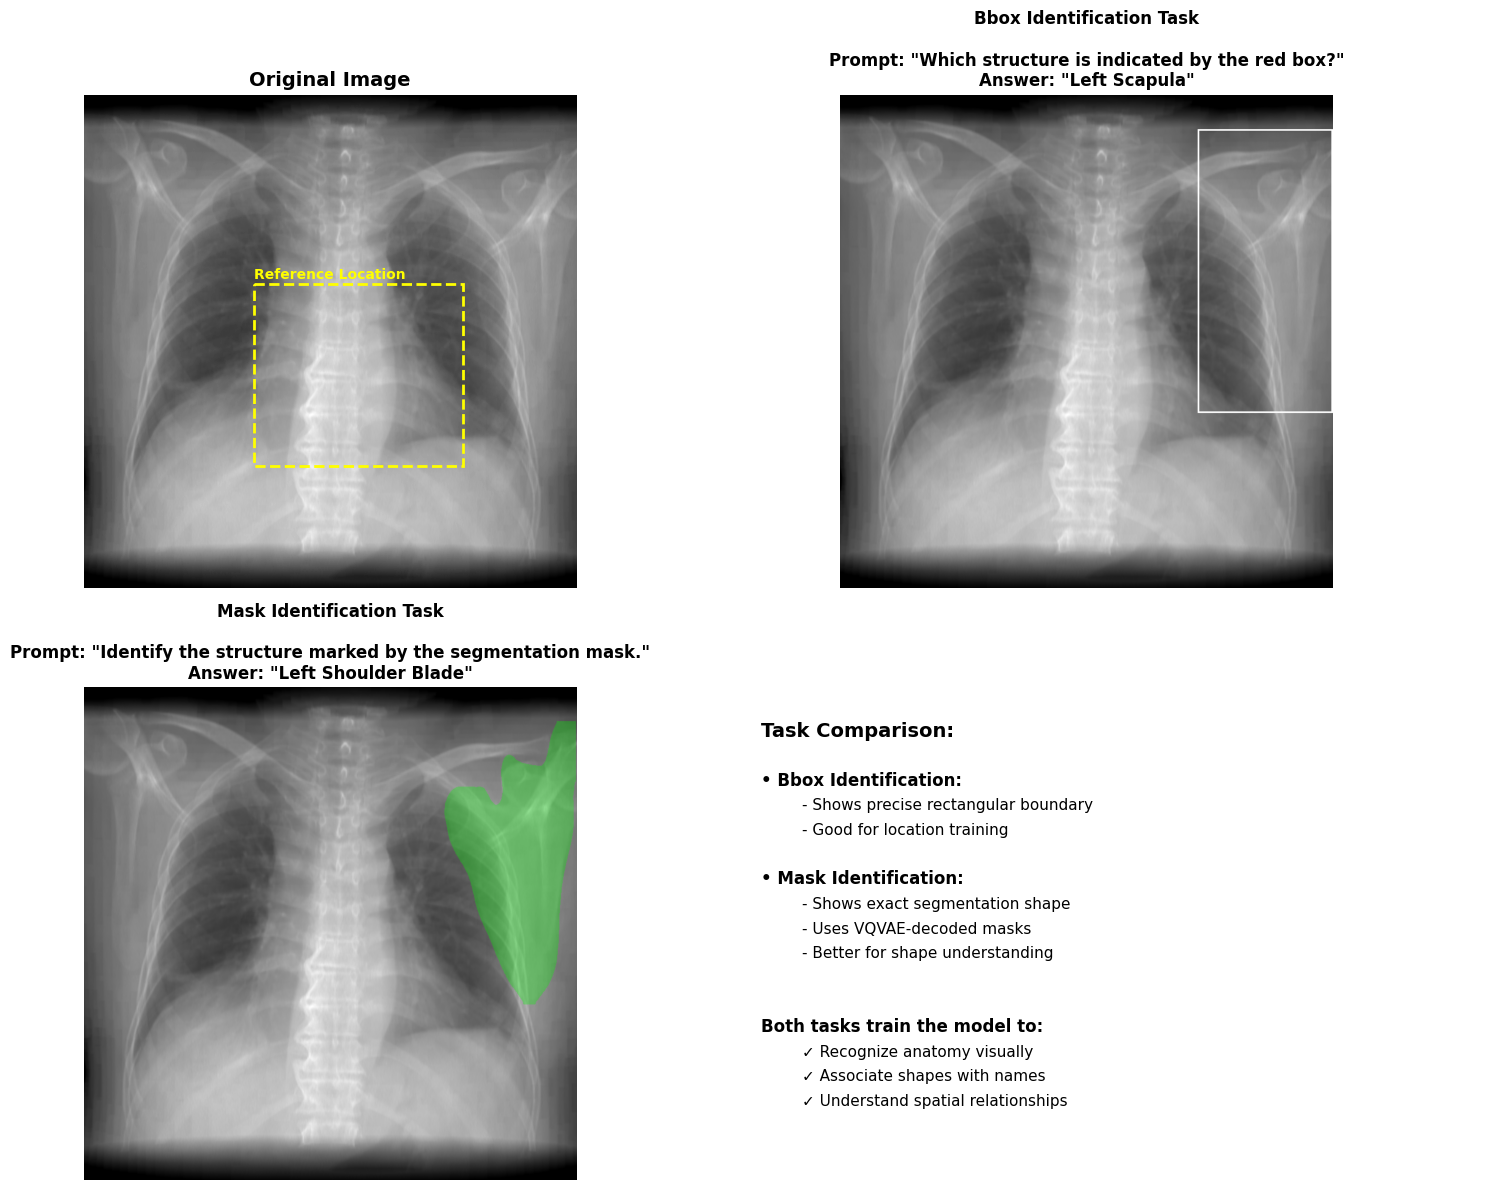


📊 Visual Task Generation Results:
Structure: scapula_left
Bbox Task - Prompt: Which structure is indicated by the red box?
Bbox Task - Answer: Left Scapula
Mask Task - Prompt: Identify the structure marked by the segmentation mask.
Mask Task - Answer: Left Shoulder Blade

🎯 Visual identification tasks add powerful training capabilities:
   • Models learn to recognize anatomy from visual cues
   • Complements token-based tasks with spatial understanding
   • Provides diverse training data for robust performance


In [27]:
# Test the new visual identification tasks with overlays
import importlib

# Import the paligemma generator 
from paligemma_generator import PaligemmaSampleGenerator
importlib.reload(sys.modules['paligemma_generator'])

print("=" * 80)
print("NEW VISUAL IDENTIFICATION TASKS DEMONSTRATION")
print("=" * 80)

# Create generator with the current NPZ data
generator = PaligemmaSampleGenerator(npz_path, enable_augmentation=False)

# Test structure
test_structure = 'scapula_left'

# Generate bbox identification sample
bbox_sample = generator.generate_sample('bbox_identification', test_structure)
mask_sample = generator.generate_sample('mask_identification', test_structure)

if bbox_sample and mask_sample:
    # Create figure with 4 panels showing the visual identification tasks
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Original image for reference
    axes[0, 0].imshow(image_array, cmap='gray')
    axes[0, 0].set_title('Original Image', fontsize=14, fontweight='bold')
    axes[0, 0].axis('off')
    
    # Add reference bounding box
    y_min, x_min, y_max, x_max = structure_info['bbox']
    rect = patches.Rectangle((x_min, y_min), x_max-x_min, y_max-y_min, 
                           linewidth=2, edgecolor='yellow', facecolor='none', linestyle='--')
    axes[0, 0].add_patch(rect)
    axes[0, 0].text(x_min, y_min-10, 'Reference Location', color='yellow', fontweight='bold')
    
    # Bbox identification task
    axes[0, 1].imshow(np.array(bbox_sample.image))
    axes[0, 1].set_title(f'Bbox Identification Task\n\nPrompt: "{bbox_sample.prefix}"\nAnswer: "{bbox_sample.suffix}"', 
                       fontsize=12, fontweight='bold')
    axes[0, 1].axis('off')
    
    # Mask identification task  
    axes[1, 0].imshow(np.array(mask_sample.image))
    axes[1, 0].set_title(f'Mask Identification Task\n\nPrompt: "{mask_sample.prefix}"\nAnswer: "{mask_sample.suffix}"', 
                       fontsize=12, fontweight='bold')
    axes[1, 0].axis('off')
    
    # Comparison panel
    axes[1, 1].axis('off')
    axes[1, 1].text(0.1, 0.9, 'Task Comparison:', fontsize=14, fontweight='bold', transform=axes[1, 1].transAxes)
    axes[1, 1].text(0.1, 0.8, '• Bbox Identification:', fontsize=12, fontweight='bold', transform=axes[1, 1].transAxes)
    axes[1, 1].text(0.15, 0.75, '- Shows precise rectangular boundary', fontsize=11, transform=axes[1, 1].transAxes)
    axes[1, 1].text(0.15, 0.7, '- Good for location training', fontsize=11, transform=axes[1, 1].transAxes)
    
    axes[1, 1].text(0.1, 0.6, '• Mask Identification:', fontsize=12, fontweight='bold', transform=axes[1, 1].transAxes)
    axes[1, 1].text(0.15, 0.55, '- Shows exact segmentation shape', fontsize=11, transform=axes[1, 1].transAxes)
    axes[1, 1].text(0.15, 0.5, '- Uses VQVAE-decoded masks', fontsize=11, transform=axes[1, 1].transAxes)
    axes[1, 1].text(0.15, 0.45, '- Better for shape understanding', fontsize=11, transform=axes[1, 1].transAxes)
    
    axes[1, 1].text(0.1, 0.3, 'Both tasks train the model to:', fontsize=12, fontweight='bold', transform=axes[1, 1].transAxes)
    axes[1, 1].text(0.15, 0.25, '✓ Recognize anatomy visually', fontsize=11, transform=axes[1, 1].transAxes)
    axes[1, 1].text(0.15, 0.2, '✓ Associate shapes with names', fontsize=11, transform=axes[1, 1].transAxes)
    axes[1, 1].text(0.15, 0.15, '✓ Understand spatial relationships', fontsize=11, transform=axes[1, 1].transAxes)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n📊 Visual Task Generation Results:")
    print(f"Structure: {test_structure}")
    print(f"Bbox Task - Prompt: {bbox_sample.prefix}")
    print(f"Bbox Task - Answer: {bbox_sample.suffix}")
    print(f"Mask Task - Prompt: {mask_sample.prefix}")  
    print(f"Mask Task - Answer: {mask_sample.suffix}")
    
else:
    print("❌ Could not generate visual identification samples")

print("\n🎯 Visual identification tasks add powerful training capabilities:")

print("   • Models learn to recognize anatomy from visual cues")
print("   • Complements token-based tasks with spatial understanding")
print("   • Provides diverse training data for robust performance")